In [1]:
!pip install kaggle

  Using cached protobuf-7.35.0-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached markdown_it_py-4.2.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
Using cached protobuf-7.35.0-cp310-abi3-win_amd64.whl (439 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
Using cached markdown_it_py-4.2.0-py3-none-any.whl (91 kB)
Using cached mdurl-0.1.2-py3-none-any.whl (10.0 kB)



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!kaggle datasets list -s telco

ref                                                          title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
blastchar/telco-customer-churn                               Telco Customer Churn                                    175758  2018-02-23 18:20:00.210000         551869       3682  0.88235295       
abdallahwagih/telco-customer-churn                           Telco Customer Churn                                   1314646  2024-10-11 05:27:55.330000           4365         72  0.88235295       
alfathterry/telco-customer-churn-11-1-3                      Telco customer churn (11.1.3+)                          525781  2024-05-08 20:46:56.010000           6200         74  1                
dhrubangtalukda

In [3]:
!kaggle datasets download -d blastchar/telco-customer-churn

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors




  0%|          | 0.00/172k [00:00<?, ?B/s]
100%|██████████| 172k/172k [00:00<00:00, 630kB/s]
100%|██████████| 172k/172k [00:00<00:00, 628kB/s]


In [4]:
import zipfile

with zipfile.ZipFile('telco-customer-churn.zip', 'r') as zip_ref:
    zip_ref.extractall('../dataset_raw')

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from sklearn.preprocessing import StandardScaler

# 2 Memuat Dataset
dataset yang digunakan adalah telco-custumer-churn yang digunakan untuk memprediksi potensi pelanggan yang akan berhenti.

In [7]:
df = pd.read_csv('../dataset_raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
df.drop('customerID', axis=1, inplace=True)

In [11]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [12]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [13]:
df.dropna(subset=['TotalCharges'], inplace=True)

In [14]:
print("Sesudah:", len(df))

Sesudah: 7032


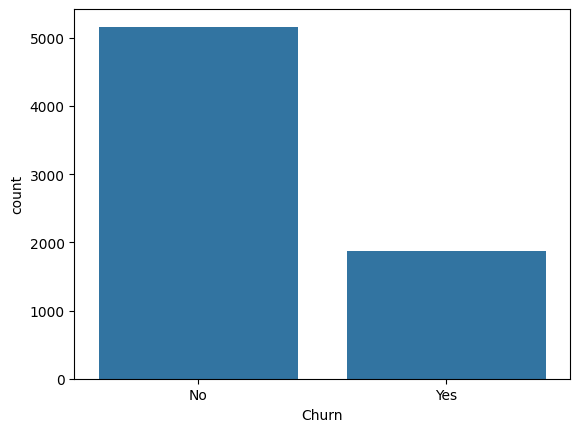

In [15]:
sns.countplot(x='Churn', data=df)
plt.show()

In [16]:
df['Churn'].value_counts(normalize=True)*100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

<Axes: xlabel='Churn', ylabel='tenure'>

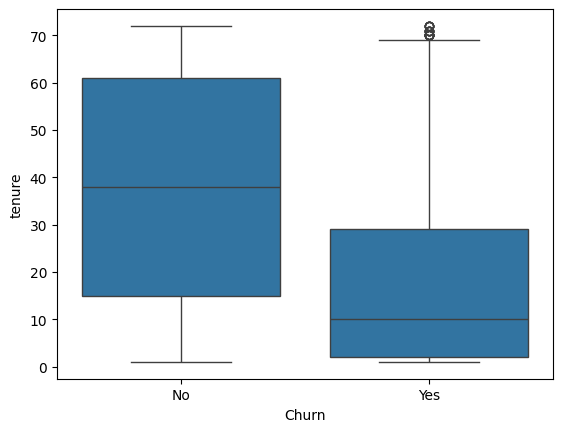

In [17]:
sns.boxplot(
    x='Churn',
    y='tenure',
    data=df
)

In [18]:
Q1 = df[df['Churn']=='Yes']['tenure'].quantile(0.25)
Q3 = df[df['Churn']=='Yes']['tenure'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['Churn']=='Yes') &
    ((df['tenure'] < lower) | (df['tenure'] > upper))
]

print("Jumlah outlier:", len(outliers))
print(outliers[['tenure']].head())

Jumlah outlier: 23
      tenure
811       70
975       71
1306      70
2879      70
3040      71


<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

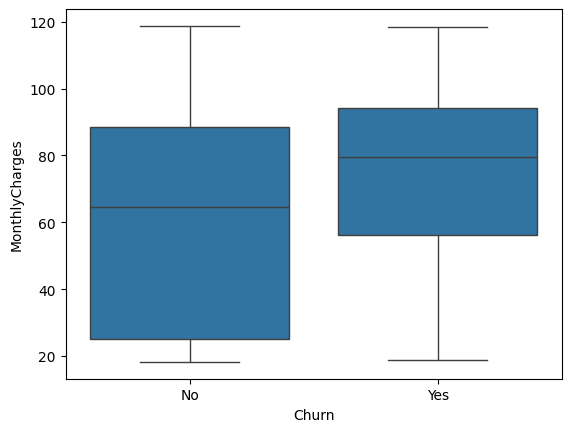

In [19]:
sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

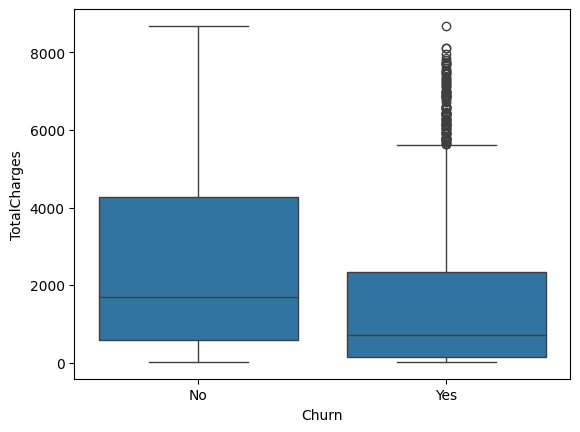

In [20]:
sns.boxplot(
    x='Churn',
    y='TotalCharges',
    data=df
)
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=6))
plt.show()

In [21]:
Q1 = df[df['Churn']=='Yes']['TotalCharges'].quantile(0.25)
Q3 = df[df['Churn']=='Yes']['TotalCharges'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['Churn']=='Yes') &
    ((df['TotalCharges'] < lower) | (df['TotalCharges'] > upper))
]

print("Jumlah outlier:", len(outliers))
print(outliers[['TotalCharges']].head())

Jumlah outlier: 109
     TotalCharges
104       7611.85
339       6603.00
402       7007.60
445       6396.45
609       6786.40


In [22]:
pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
)*100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


<Axes: xlabel='Contract', ylabel='count'>

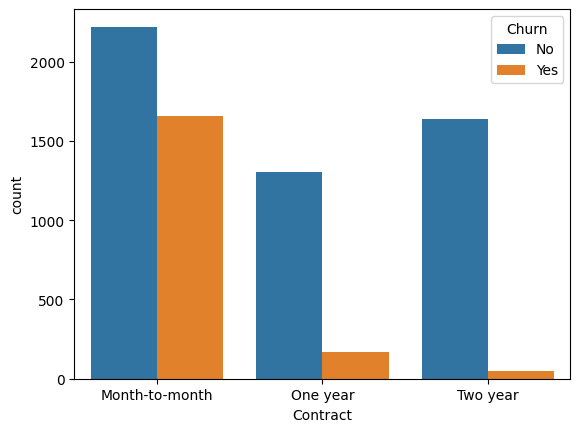

In [23]:
sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

<Axes: xlabel='InternetService', ylabel='count'>

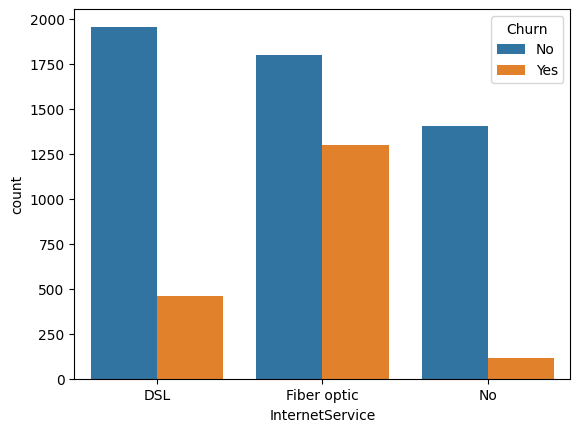

In [24]:
sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)

<Axes: xlabel='count', ylabel='PaymentMethod'>

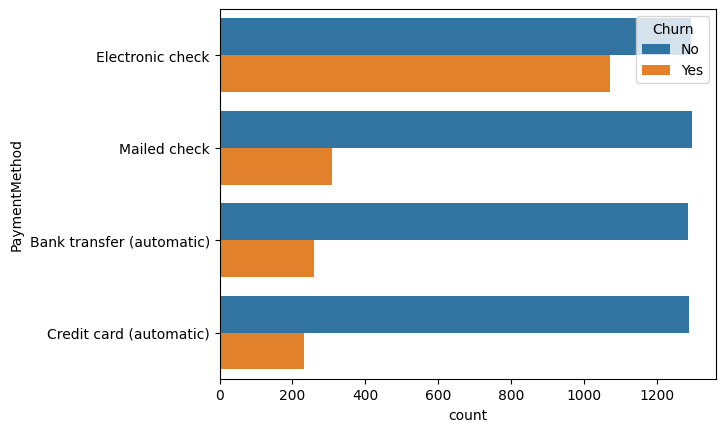

In [25]:
sns.countplot(
    y='PaymentMethod',
    hue='Churn',
    data=df
)

In [26]:
df['Churn'] = df['Churn'].map({
    'No':0,
    'Yes':1
})

In [27]:
binary_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

for col in binary_cols:
    print(df[col].unique())
    

<StringArray>
['Female', 'Male']
Length: 2, dtype: str
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
<StringArray>
['Yes', 'No']
Length: 2, dtype: str


In [28]:
df_encoded = pd.get_dummies(df, drop_first=True).astype(int)

In [29]:
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29,29,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56,1889,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53,108,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42,1840,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70,151,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


In [30]:
scaler = StandardScaler()
num_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

In [31]:
import os
os.makedirs("dataset_preprocessing", exist_ok=True)
df_encoded.to_csv('./dataset_preprocessing/telco_preprocessed.csv', index=False)
